# Preparación inicial

In [1]:
# Para descargar los paquetes
# !pip install interpret
# %conda install -c conda-forge interpret -y

## Librerías

In [2]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import itertools
import re

# Librerías para el EBM
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

## Carga de datos

In [3]:
datos = pd.read_csv('data/estudiantes.csv', sep=';').copy()

# Modificación de datos

Se realiza una función para limpiar los nombres de los datos.

In [4]:
def clean_names(df):
    """
    Limpia y estandariza los nombres de columnas de un DataFrame.

    Convierte los nombres a minúsculas, elimina caracteres especiales y
    reemplaza espacios por guiones bajos.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame cuyos nombres de columnas se desean limpiar.

    Returns
    -------
    None
        Modifica el DataFrame en su lugar.
    """
    df.columns = [
        re.sub(r'_+', '_', re.sub(r'\s+', '_', re.sub(r'[^\w\s]', '', str(col).strip().lower().encode("ascii", "ignore").decode()))).strip('_')
        for col in df.columns
    ]

In [5]:
# Se limpian los nombres de las columnas
clean_names(datos)

# Nuevos nombres de columnas
datos.columns

Index(['marital_status', 'application_mode', 'application_order', 'course',
       'daytimeevening_attendance', 'previous_qualification',
       'previous_qualification_grade', 'nacionality', 'mothers_qualification',
       'fathers_qualification', 'mothers_occupation', 'fathers_occupation',
       'admission_grade', 'displaced', 'educational_special_needs', 'debtor',
       'tuition_fees_up_to_date', 'gender', 'scholarship_holder',
       'age_at_enrollment', 'international',
       'curricular_units_1st_sem_credited',
       'curricular_units_1st_sem_enrolled',
       'curricular_units_1st_sem_evaluations',
       'curricular_units_1st_sem_approved', 'curricular_units_1st_sem_grade',
       'curricular_units_1st_sem_without_evaluations',
       'curricular_units_2nd_sem_credited',
       'curricular_units_2nd_sem_enrolled',
       'curricular_units_2nd_sem_evaluations',
       'curricular_units_2nd_sem_approved', 'curricular_units_2nd_sem_grade',
       'curricular_units_2nd_sem_with

Ahora, para dejar únicamente 2 categorías, se mantienen los estudiantes graduados o los que cometieron deserción.

In [6]:
# Se omiten los estudiantes matriculados, para dejar únicamente a los graduados y a los que cometieron deserción universitaria
datos = datos[datos['target'] != 'Enrolled'].copy()

# Se renueva el índice de la fila
datos = datos.reset_index(drop=True)

# Se muestran las dimensiones finales
datos.shape

(3630, 37)

Luego, para comprender los datos de manera más sencilla, se cambian las variables categóricas a textos más fáciles de interpretar.

In [7]:
# Diccionario para mapear el estado civil
dic_mapeo = {
    1: 'soltero/a',
    2: 'casado/a',
    3: 'viudo/a',
    4: 'divorciado/a',
    5: 'unión libre',
    6: 'separado/a'
}

# Se redefine el formato del estado civil, para mayor comprensión
datos['marital_status'] = datos['marital_status'].map(dic_mapeo).astype('category')

# Diccionario para mapear el modo de aplicación
dic_mapeo = {
    1: 'contingente general - primera fase',
    2: 'ordenanza 612/93',
    5: 'Azores - primera fase',
    7: 'titulares de cursos superiores',
    10: 'ordenanza 854-B/99',
    15: 'estudiante internacional (bachillerato)',
    16: 'Madeira - primera fase',
    17: 'contingente general - segunda fase',
    18: 'contingente general - tercera fase',
    26: 'plan diferente',
    27: 'otra institución',
    39: 'más de 23 años',
    42: 'transferencia',
    43: 'cambio de curso',
    44: 'especialización tecnológica',
    51: 'cambio de institución/curso',
    53: 'titulares de diplomas de ciclo corto',
    57: 'cambio de institución/curso (internacional)'
}

# Se redefine el formato del modo de aplicación
datos['application_mode'] = datos['application_mode'].map(dic_mapeo).astype('category')

# Se redefine el formato del orden de aplicación
datos['application_order'] = datos['application_order'].astype('category')

# Diccionario para mapear el curso
dic_mapeo = {
    33: 'tecnologías de producción de biocombustibles',
    171: 'diseño de animación y multimedia',
    8014: 'servicio social (turno nocturno)',
    9003: 'agronomía',
    9070: 'diseño de comunicación',
    9085: 'enfermería veterinaria',
    9119: 'ingeniería informática',
    9130: 'equinicultura',
    9147: 'gestión',
    9238: 'servicio social',
    9254: 'turismo',
    9500: 'enfermería',
    9556: 'higiene oral',
    9670: 'gestión de publicidad y marketing',
    9773: 'periodismo y comunicación',
    9853: 'educación básica',
    9991: 'gestión (turno nocturno)'
}

# Se redefine el formato de los cursos
datos['course'] = datos['course'].map(dic_mapeo).astype('category')

# Diccionario para la jornada a la que reciben clases
dic_mapeo = {
    1: 'diurna',
    0: 'nocturna'
}

# Se redefine el formato del momento de 
datos['daytimeevening_attendance'] = datos['daytimeevening_attendance'].map(dic_mapeo).astype('category')

# Diccionario para ver la titulación previa
dic_mapeo = {
    1: 'educación secundaria',
    2: 'licenciatura',
    3: 'grado',
    4: 'maestría',
    5: 'doctorado',
    6: 'frecuencia de educación superior',
    9: '12° año de escolaridad - no completado',
    10: '11° año de escolaridad - no completado',
    12: 'otro - 11° año de escolaridad',
    14: '10° año de escolaridad',
    15: '10° año de escolaridad - no completado',
    19: 'educación básica 3er ciclo (9°/10°/11° año)',
    38: 'educación básica 2do ciclo (6°/7°/8° año)',
    39: 'curso de especialización tecnológica',
    40: 'educación superior - grado (1er ciclo)',
    42: 'curso técnico superior profesional',
    43: 'educación superior - maestría (2do ciclo)'
}

# Se redefine la titulación previa
datos['previous_qualification'] = datos['previous_qualification'].map(dic_mapeo).astype('category')

# Diccionario con las nacionalidades
dic_mapeo = {
    1: 'portugués/a',
    2: 'alemán/a',
    6: 'español/a',
    11: 'italiano/a',
    13: 'neerlandés/a',
    14: 'inglés/a',
    17: 'lituano/a',
    21: 'angoleño/a',
    22: 'caboverdiano/a',
    24: 'guineano/a',
    25: 'mozambiqueño/a',
    26: 'santotomense',
    32: 'turco/a',
    41: 'brasileño/a',
    62: 'rumano/a',
    100: 'moldavo/a',
    101: 'mexicano/a',
    103: 'ucraniano/a',
    105: 'ruso/a',
    108: 'cubano/a',
    109: 'colombiano/a'
}

# Se redefine la nacionalidad
datos['nacionality'] = datos['nacionality'].map(dic_mapeo).astype('category')

# Diccionario para la titulación de la madre
dic_mapeo = {
    1: 'educación secundaria - 12° año o equiv.',
    2: 'educación superior - licenciatura',
    3: 'educación superior - grado',
    4: 'educación superior - maestría',
    5: 'educación superior - doctorado',
    6: 'frecuencia de educación superior',
    9: '12° año de escolaridad - no completado',
    10: '11° año de escolaridad - no completado',
    11: '7° año (antiguo)',
    12: 'otro - 11° año de escolaridad',
    14: '10° año de escolaridad',
    18: 'curso general de comercio',
    19: 'educación básica 3er ciclo (9°/10°/11° año) o equiv.',
    22: 'curso técnico-profesional',
    26: '7° año de escolaridad',
    27: '2do ciclo del curso general de bachillerato',
    29: '9° año de escolaridad - no completado',
    30: '8° año de escolaridad',
    34: 'desconocido',
    35: 'no sabe leer ni escribir',
    36: 'sabe leer sin tener 4° año de escolaridad',
    37: 'educación básica 1er ciclo (4°/5° año) o equiv.',
    38: 'educación básica 2do ciclo (6°/7°/8° año) o equiv.',
    39: 'curso de especialización tecnológica',
    40: 'educación superior - grado (1er ciclo)',
    41: 'curso de estudios superiores especializados',
    42: 'curso técnico superior profesional',
    43: 'educación superior - maestría (2do ciclo)',
    44: 'educación superior - doctorado (3er ciclo)'
}

# Se redefine la titulación de la madre
datos['mothers_qualification'] = datos['mothers_qualification'].map(dic_mapeo).astype('category')

# Diccionario para la titulación del padre
dic_mapeo = {
    1: 'educación secundaria - 12° año o equiv.',
    2: 'educación superior - licenciatura',
    3: 'educación superior - grado',
    4: 'educación superior - maestría',
    5: 'educación superior - doctorado',
    6: 'frecuencia de educación superior',
    9: '12° año de escolaridad - no completado',
    10: '11° año de escolaridad - no completado',
    11: '7° año (antiguo)',
    12: 'otro - 11° año de escolaridad',
    13: '2do año del curso complementario de bachillerato',
    14: '10° año de escolaridad',
    18: 'curso general de comercio',
    19: 'educación básica 3er ciclo (9°/10°/11° año) o equiv.',
    20: 'curso complementario de bachillerato',
    22: 'curso técnico-profesional',
    25: 'curso complementario de bachillerato - no concluido',
    26: '7° año de escolaridad',
    27: '2do ciclo del curso general de bachillerato',
    29: '9° año de escolaridad - no completado',
    30: '8° año de escolaridad',
    31: 'curso general de administración y comercio',
    33: 'contabilidad y administración suplementaria',
    34: 'desconocido',
    35: 'no sabe leer ni escribir',
    36: 'sabe leer sin tener 4° año de escolaridad',
    37: 'educación básica 1er ciclo (4°/5° año) o equiv.',
    38: 'educación básica 2do ciclo (6°/7°/8° año) o equiv.',
    39: 'curso de especialización tecnológica',
    40: 'educación superior - grado (1er ciclo)',
    41: 'curso de estudios superiores especializados',
    42: 'curso técnico superior profesional',
    43: 'educación superior - maestría (2do ciclo)',
    44: 'educación superior - doctorado (3er ciclo)'
}

# Se redefine la titulación del padre
datos['fathers_qualification'] = datos['fathers_qualification'].map(dic_mapeo).astype('category')

# Diccionario para la ocupación de la madre
dic_mapeo = {
    0: 'estudiante',
    1: 'representantes del poder legislativo y ejecutivo, directores y gerentes',
    2: 'especialistas en actividades intelectuales y científicas',
    3: 'técnicos y profesionales de nivel intermedio',
    4: 'personal administrativo',
    5: 'trabajadores de servicios personales, seguridad y vendedores',
    6: 'agricultores y trabajadores cualificados en agricultura, pesca y silvicultura',
    7: 'trabajadores cualificados en industria, construcción y artesanía',
    8: 'operadores de instalaciones y máquinas y trabajadores de montaje',
    9: 'trabajadores no cualificados',
    10: 'profesiones de las fuerzas armadas',
    90: 'otra situación',
    99: '(en blanco)',
    122: 'profesionales de la salud',
    123: 'docentes',
    125: 'especialistas en tecnologías de la información y comunicación (TIC)',
    131: 'técnicos de nivel intermedio en ciencias e ingeniería',
    132: 'técnicos y profesionales de nivel intermedio en salud',
    134: 'técnicos de nivel intermedio en servicios jurídicos, sociales, deportivos, culturales y similares',
    141: 'empleados de oficina, secretarios y operadores de procesamiento de datos',
    143: 'operadores de servicios de datos, contabilidad, estadística, financieros y de registro',
    144: 'otro personal de apoyo administrativo',
    151: 'trabajadores de servicios personales',
    152: 'vendedores',
    153: 'trabajadores de cuidado personal y similares',
    171: 'trabajadores cualificados en construcción y similares, excepto electricistas',
    173: 'trabajadores cualificados en imprenta, fabricación de instrumentos de precisión, joyería y artesanía',
    175: 'trabajadores en procesamiento de alimentos, carpintería, confección y otras industrias',
    191: 'trabajadores de limpieza',
    192: 'trabajadores no cualificados en agricultura, producción animal, pesca y silvicultura',
    193: 'trabajadores no cualificados en industria extractiva, construcción, manufactura y transporte',
    194: 'asistentes de preparación de alimentos'
}

# Se redefine la ocupación de la madre
datos['mothers_occupation'] = datos['mothers_occupation'].map(dic_mapeo).astype('category')

# Diccionario para la ocupación del padre
dic_mapeo = {
    0: 'estudiante',
    1: 'representantes del poder legislativo y ejecutivo, directores y gerentes',
    2: 'especialistas en actividades intelectuales y científicas',
    3: 'técnicos y profesionales de nivel intermedio',
    4: 'personal administrativo',
    5: 'trabajadores de servicios personales, seguridad y vendedores',
    6: 'agricultores y trabajadores cualificados en agricultura, pesca y silvicultura',
    7: 'trabajadores cualificados en industria, construcción y artesanía',
    8: 'operadores de instalaciones y máquinas y trabajadores de montaje',
    9: 'trabajadores no cualificados',
    10: 'profesiones de las fuerzas armadas',
    90: 'otra situación',
    99: '(en blanco)',
    101: 'oficiales de las fuerzas armadas',
    102: 'sargentos de las fuerzas armadas',
    103: 'otro personal de las fuerzas armadas',
    112: 'directores de servicios administrativos y comerciales',
    114: 'directores de hostelería, restauración, comercio y otros servicios',
    121: 'especialistas en ciencias físicas, matemáticas, ingeniería y técnicas afines',
    122: 'profesionales de la salud',
    123: 'docentes',
    124: 'especialistas en finanzas, contabilidad, organización administrativa y relaciones públicas y comerciales',
    131: 'técnicos de nivel intermedio en ciencias e ingeniería',
    132: 'técnicos y profesionales de nivel intermedio en salud',
    134: 'técnicos de nivel intermedio en servicios jurídicos, sociales, deportivos, culturales y similares',
    135: 'técnicos en tecnologías de la información y comunicación',
    141: 'empleados de oficina, secretarios y operadores de procesamiento de datos',
    143: 'operadores de servicios de datos, contabilidad, estadística, financieros y de registro',
    144: 'otro personal de apoyo administrativo',
    151: 'trabajadores de servicios personales',
    152: 'vendedores',
    153: 'trabajadores de cuidado personal y similares',
    154: 'personal de servicios de protección y seguridad',
    161: 'agricultores y trabajadores cualificados en producción agrícola y animal orientada al mercado',
    163: 'agricultores, ganaderos, pescadores, cazadores y recolectores de subsistencia',
    171: 'trabajadores cualificados en construcción y similares, excepto electricistas',
    172: 'trabajadores cualificados en metalurgia, trabajo de metales y similares',
    174: 'trabajadores cualificados en electricidad y electrónica',
    175: 'trabajadores en procesamiento de alimentos, carpintería, confección y otras industrias',
    181: 'operadores de plantas e instalaciones fijas',
    182: 'trabajadores de montaje',
    183: 'conductores de vehículos y operadores de equipos móviles',
    192: 'trabajadores no cualificados en agricultura, producción animal, pesca y silvicultura',
    193: 'trabajadores no cualificados en industria extractiva, construcción, manufactura y transporte',
    194: 'asistentes de preparación de alimentos',
    195: 'vendedores ambulantes (excepto alimentos) y proveedores de servicios callejeros'
}

# Se redefine la ocupación del padre
datos['fathers_occupation'] = datos['fathers_occupation'].map(dic_mapeo).astype('category')

# Diccionario para desplazamiento
dic_mapeo = {
    1: 'sí',
    0: 'no'
}

# Se redefine si el estudiante fue desplazado
datos['displaced'] = datos['displaced'].map(dic_mapeo).astype('category')

# Se redefine si el estudiante tiene necesidades especiales
datos['educational_special_needs'] = datos['educational_special_needs'].map(dic_mapeo).astype('category')

# Se redefine si el estudiante tiene deuda
datos['debtor'] = datos['debtor'].map(dic_mapeo).astype('category')

# Se redefine si el estudiante tiene las tasas de matrícula actualizadas
datos['tuition_fees_up_to_date'] = datos['tuition_fees_up_to_date'].map(dic_mapeo).astype('category')

# Se redefine si el estudiante tiene beca
datos['scholarship_holder'] = datos['scholarship_holder'].map(dic_mapeo).astype('category')

# Se redefine si el estudiante es de otro país
datos['international'] = datos['international'].map(dic_mapeo).astype('category')

# Diccionario para mapear el género
dic_mapeo = {
    1: 'masculino',
    0: 'femenino'
}

# Se redefine la variable de género
datos['gender'] = datos['gender'].map(dic_mapeo).astype('category')

In [8]:
datos

,marital_status,application_mode,application_order,course,daytimeevening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,soltero/a,contingente general - segunda fase,5,diseño de animación y multimedia,diurna,educación secundaria,122.0,portugués/a,educación básica 3er ciclo (9°/10°/11° año) o ...,otro - 11° año de escolaridad,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,soltero/a,estudiante internacional (bachillerato),1,turismo,diurna,educación secundaria,160.0,portugués/a,educación secundaria - 12° año o equiv.,educación superior - grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,soltero/a,contingente general - primera fase,5,diseño de comunicación,diurna,educación secundaria,122.0,portugués/a,educación básica 1er ciclo (4°/5° año) o equiv.,educación básica 1er ciclo (4°/5° año) o equiv.,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,soltero/a,contingente general - segunda fase,2,periodismo y comunicación,diurna,educación secundaria,122.0,portugués/a,educación básica 2do ciclo (6°/7°/8° año) o eq...,educación básica 1er ciclo (4°/5° año) o equiv.,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,casado/a,más de 23 años,1,servicio social (turno nocturno),nocturna,educación secundaria,100.0,portugués/a,educación básica 1er ciclo (4°/5° año) o equiv.,educación básica 2do ciclo (6°/7°/8° año) o eq...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3625,soltero/a,contingente general - primera fase,6,periodismo y comunicación,diurna,educación secundaria,125.0,portugués/a,educación secundaria - 12° año o equiv.,educación secundaria - 12° año o equiv.,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
3626,soltero/a,contingente general - primera fase,2,periodismo y comunicación,diurna,educación secundaria,120.0,ruso/a,educación secundaria - 12° año o equiv.,educación secundaria - 12° año o equiv.,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
3627,soltero/a,contingente general - primera fase,1,enfermería,diurna,educación secundaria,154.0,portugués/a,educación básica 1er ciclo (4°/5° año) o equiv.,educación básica 1er ciclo (4°/5° año) o equiv.,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
3628,soltero/a,contingente general - primera fase,1,gestión,diurna,educación secundaria,180.0,portugués/a,educación básica 1er ciclo (4°/5° año) o equiv.,educación básica 1er ciclo (4°/5° año) o equiv.,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [9]:
# Lista con el nombre de las columnas del DataFrame para usarlas como etiquetas en los gráficos
names_cols = [
    "Estado civil",
    "Modo de aplicación",
    "Orden de aplicación",
    "Carrera",
    "Jornada",
    "Titulación previa",
    "Nota de calificación previa",
    "Nacionalidad",
    "Nivel educativo de la madre",
    "Nivel educativo del padre",
    "Ocupación de la madre",
    "Ocupación del padre",
    "Nota de admisión",
    "Desplazado",
    "Necesidades educativas especiales",
    "Deudor",
    "Matrícula al día",
    "Género",
    "Beca",
    "Edad al ingresar",
    "Estudiante internacional",
    "Créditos convalidados (1er semestre)",
    "Unidades matriculadas (1er semestre)",
    "Evaluaciones realizadas (1er semestre)",
    "Unidades aprobadas (1er semestre)",
    "Promedio (1er semestre)",
    "Unidades sin evaluación (1er semestre)",
    "Créditos convalidados (2do semestre)",
    "Unidades matriculadas (2do semestre)",
    "Evaluaciones realizadas (2do semestre)",
    "Unidades aprobadas (2do semestre)",
    "Promedio (2do semestre)",
    "Unidades sin evaluación (2do semestre)",
    "Tasa de desempleo",
    "Tasa de inflación",
    "PIB",
    "Estado académico"
]

def name_col(col, df = datos, names_cols = names_cols):
    """
    Devuelve el nombre de la columna de un DataFrame para usarlo como etiqueta en los gráficos
    
    Parameters
    ----------
    col : str
        Nombre crudo de una columna del DataFrame
    
    df : pd.DataFrame
        DataFrame del que se quiere obtener el nombre de la columna
    
    names_cols : list
        Lista con los nombres de las columnas que se quieren usar como etiquetas en los gráficos

    Returns
    -------
    label_col : str
        Nombre de la columna del DataFrame para usarse como etiqueta en los gráficos
    """
    
    # Nombres crudos de las columnas del DataFrame
    cols = df.columns
    
    # DataFrame con las columnas crudas y bonitas
    df_cols = pd.DataFrame({
        "cols_crudas": cols,
        "cols_bonitas": names_cols
    })
    
    label_col = df_cols.loc[df_cols["cols_crudas"] == col, "cols_bonitas"].iloc[0]
    
    return label_col

# Gráficos

## De barras

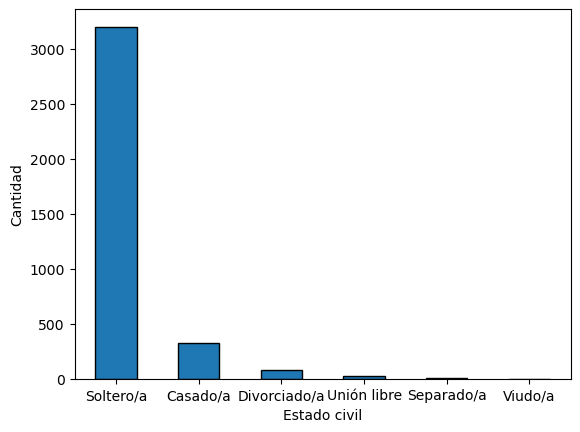

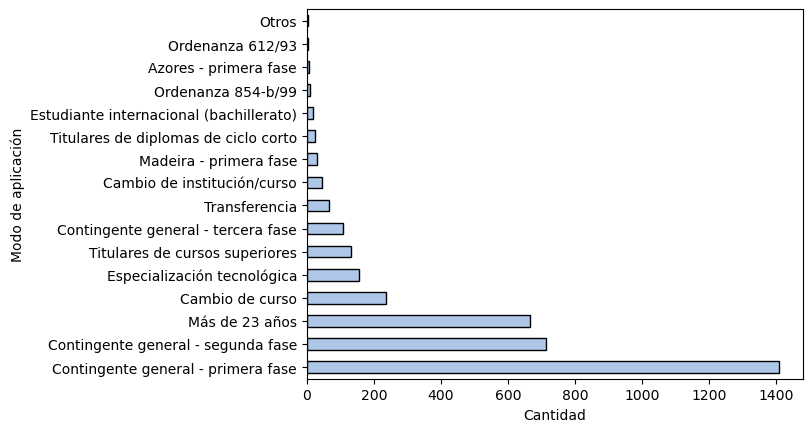

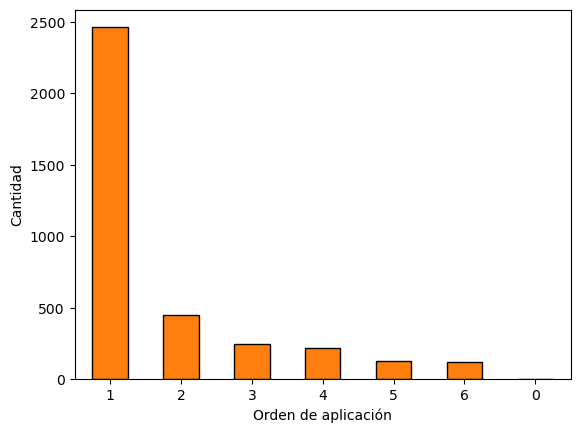

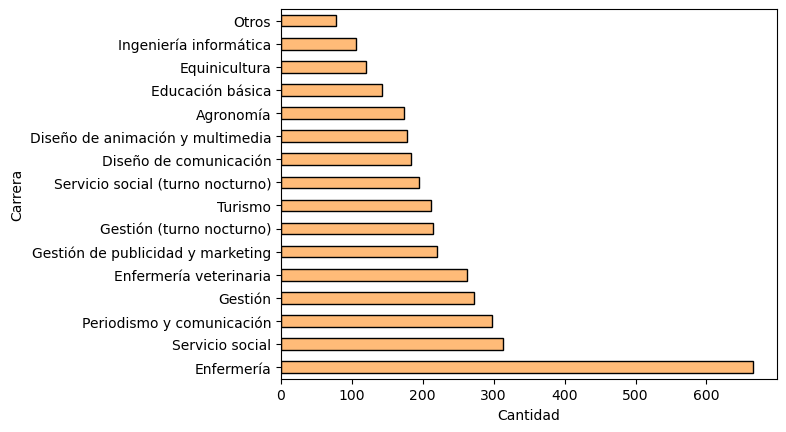

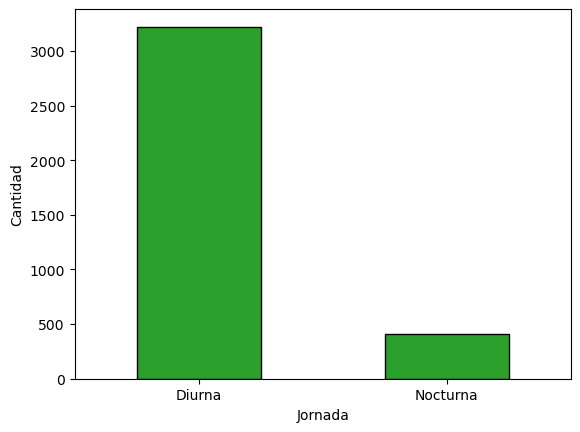

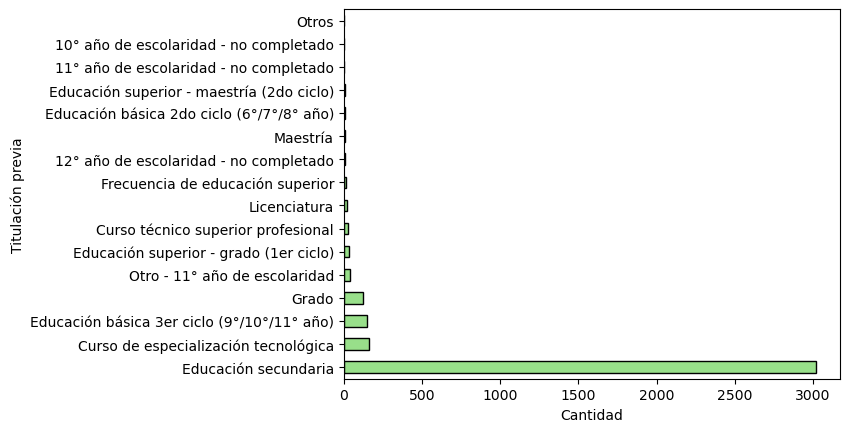

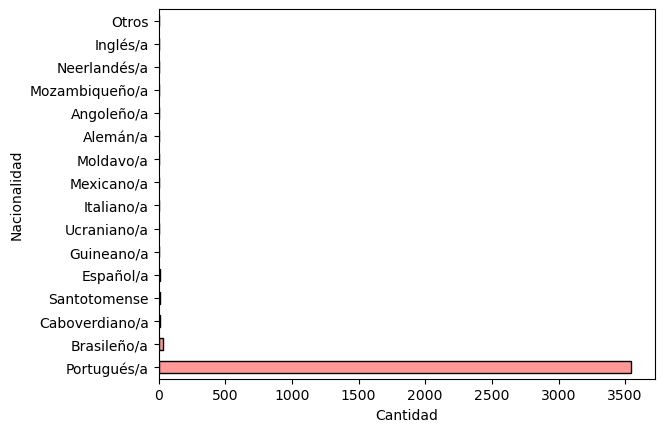

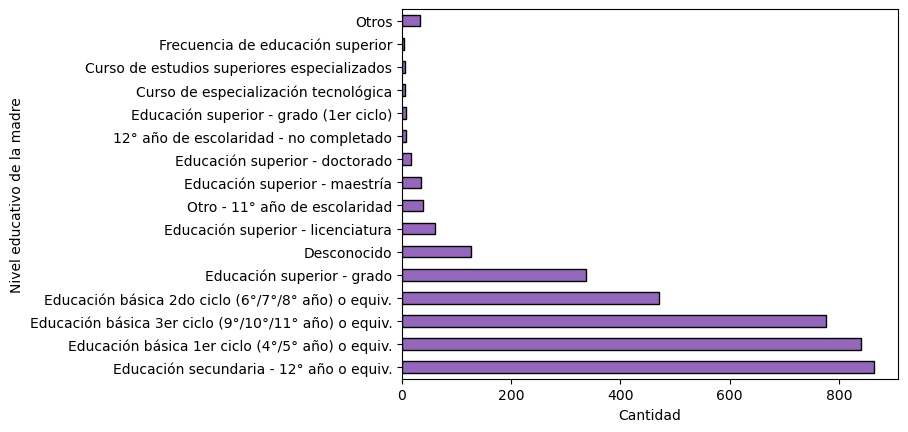

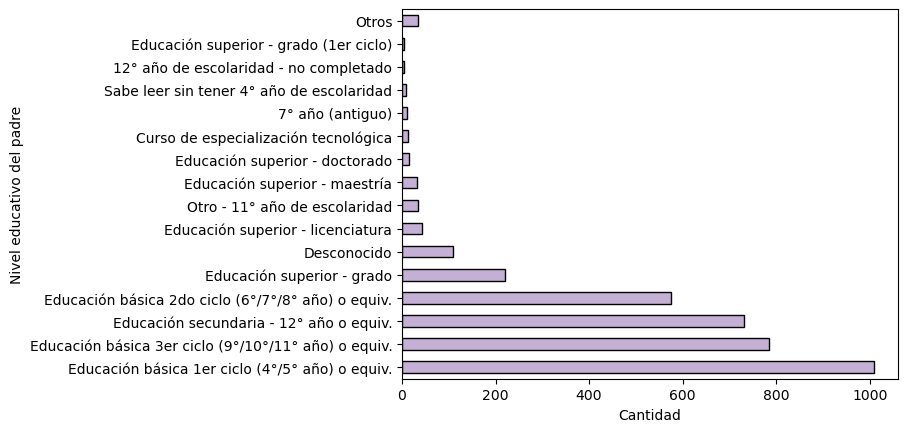

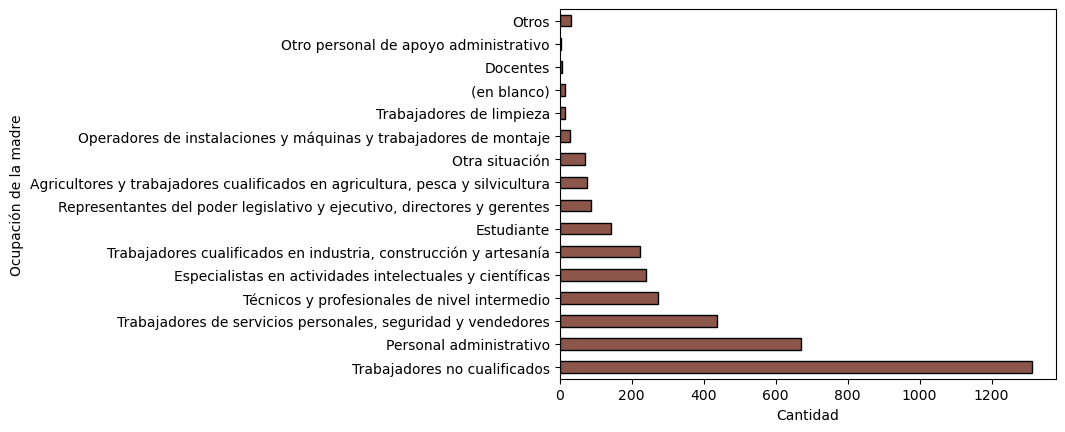

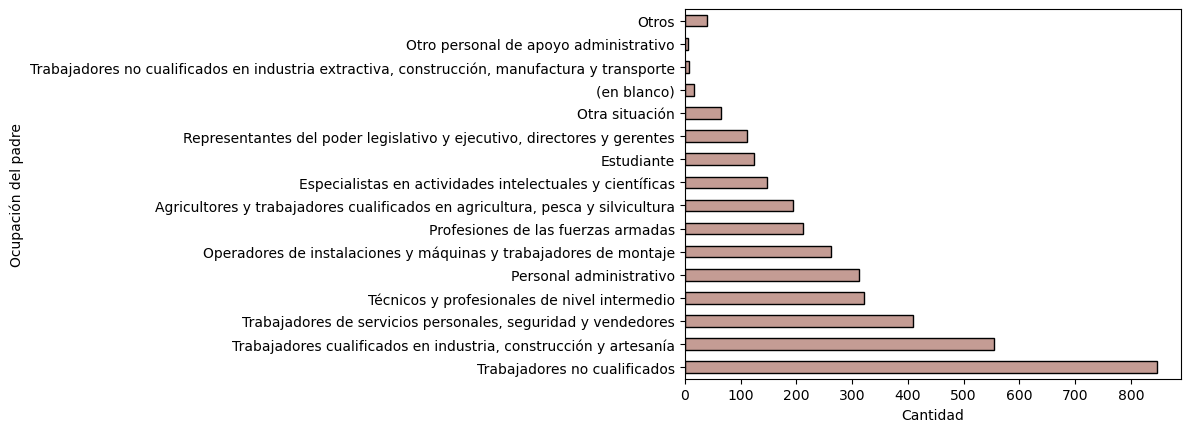

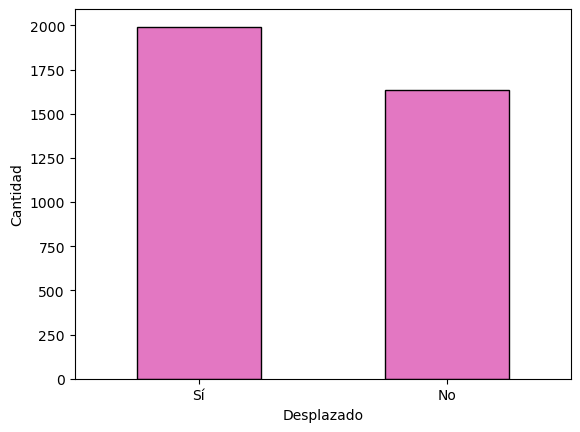

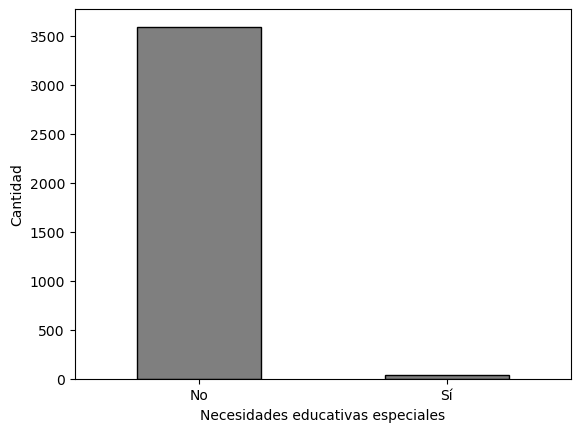

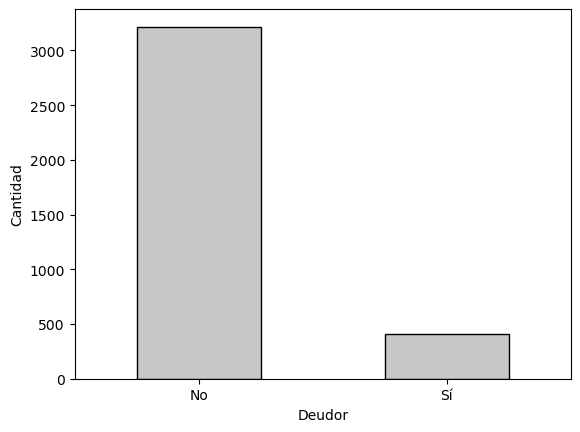

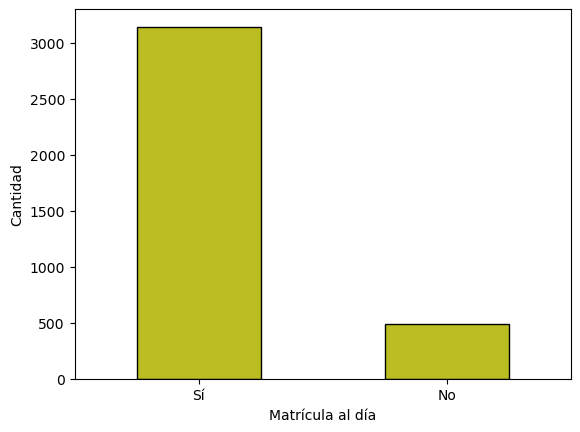

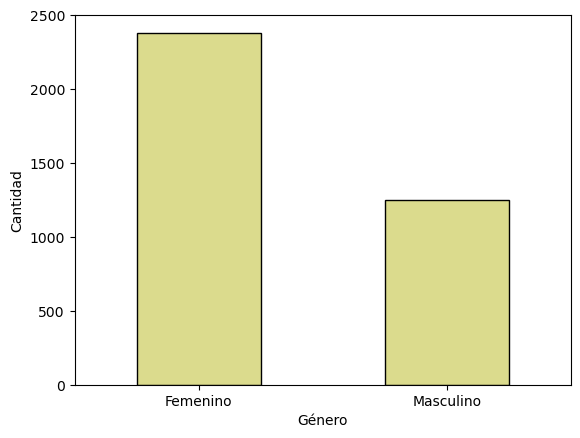

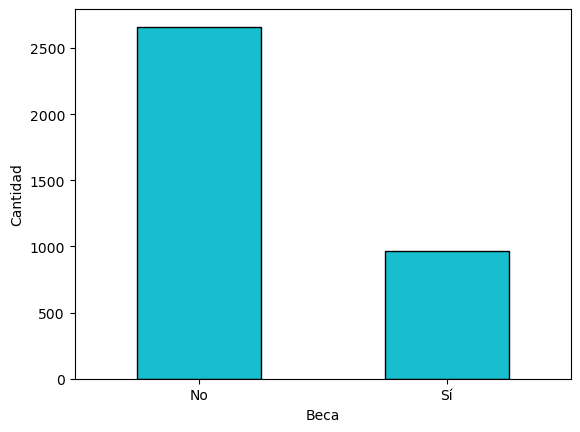

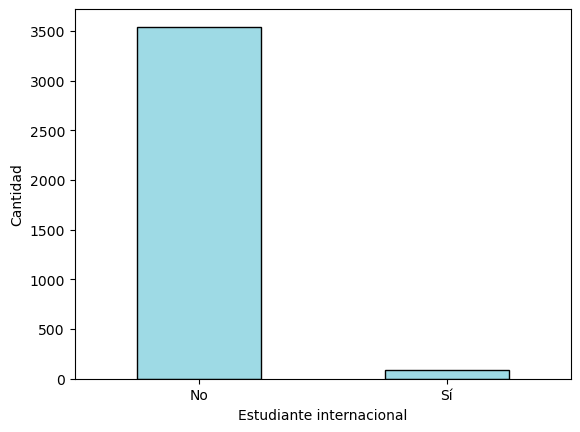

In [10]:
# Variables de tipo categórico
cols_ctgry = datos.select_dtypes(include = "category").columns

# Colores a usar en los gráficos
n = len(cols_ctgry)
colors = plt.cm.tab20(np.linspace(0, 1, n))

# N categorías más frecuentes y las demás en "Otros"
top_n = 15

# Se grafica para cada variable
for i, col in enumerate(cols_ctgry):
    # Frecuencias de cada categoría
    conteo = datos[col].value_counts()
    
    # Si tiene más de 7 categorías se aplica el top N
    if len(conteo) > 7:
        top = conteo.head(top_n)
        otros = conteo.iloc[top_n:].sum()

        if otros > 0:
            top["Otros"] = otros

        conteo = top
        
        # Se le pone mayúscula inicial a las etiquetas de las categorías
        conteo.index = conteo.index.map(lambda x: str(x).capitalize())

        # Se grafica
        conteo.plot(kind = "barh", color=colors[i], edgecolor = "black")

        plt.ylabel(name_col(col))
        plt.xlabel("Cantidad")
        plt.xticks(rotation = 0)
        plt.show()
    else:
        
        # Se le pone mayúscula inicial a las etiquetas de las categorías
        conteo.index = conteo.index.map(lambda x: str(x).capitalize())

        # Se grafica
        conteo.plot(kind = "bar", color = colors[i], edgecolor = "black")

        plt.xlabel(name_col(col))
        plt.ylabel("Cantidad")
        plt.xticks(rotation=0)
        plt.show()

## Histogramas

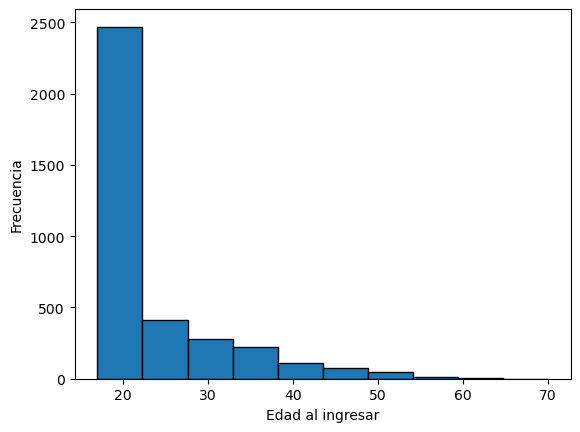

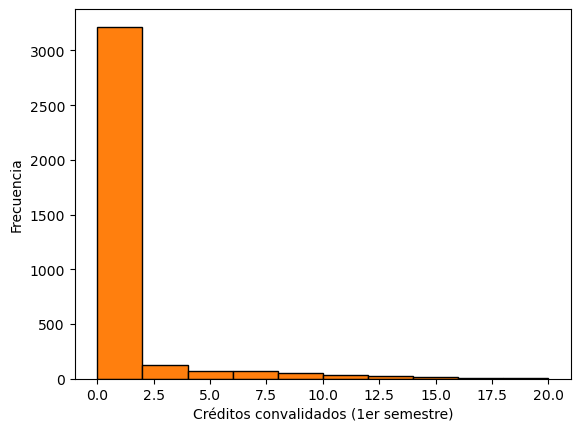

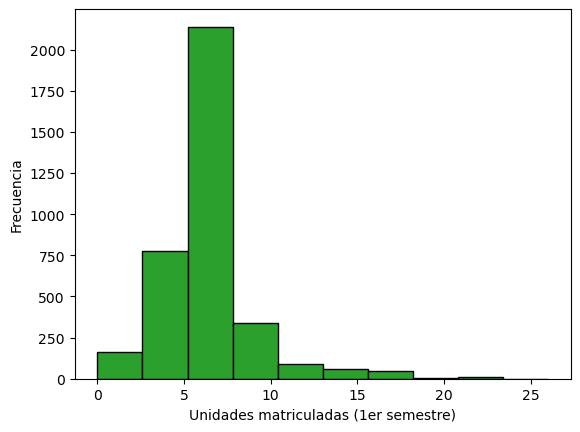

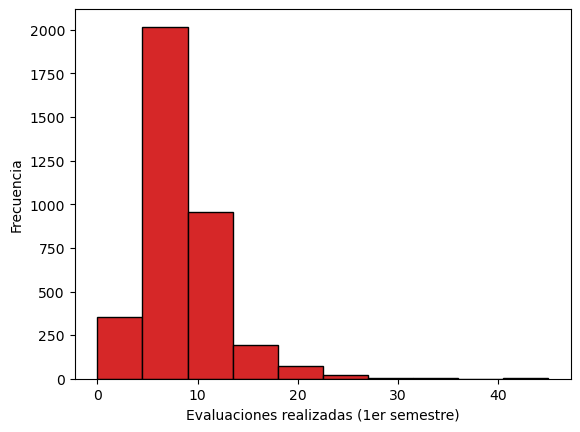

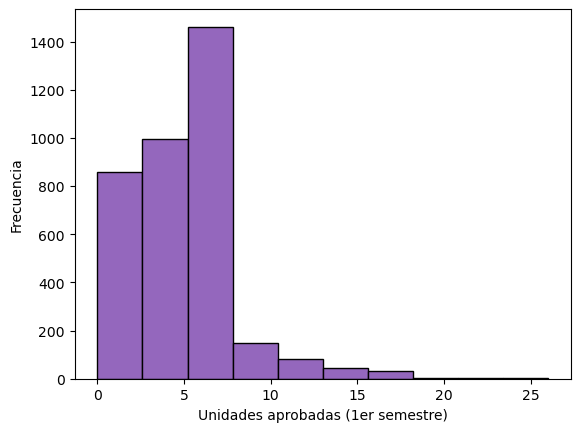

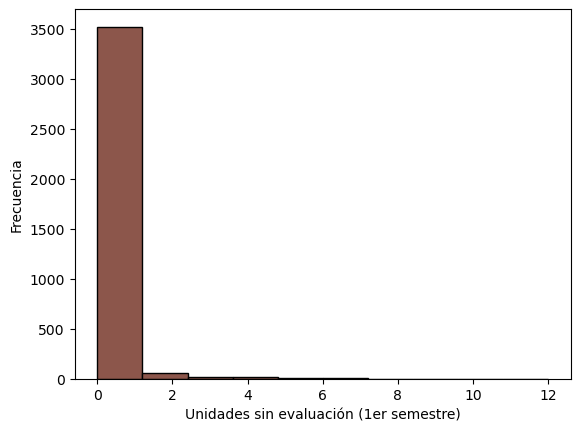

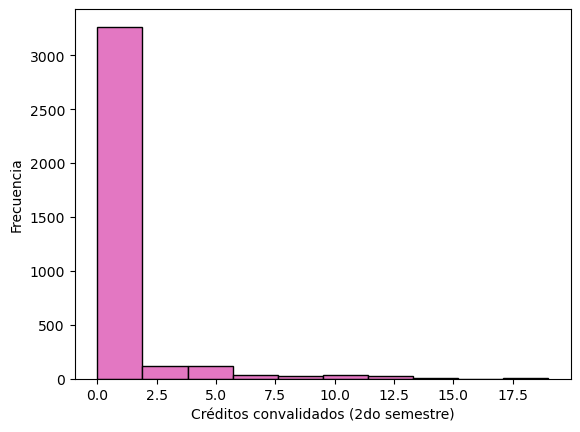

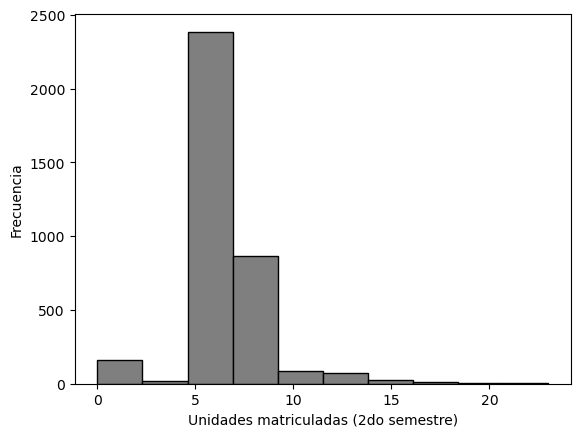

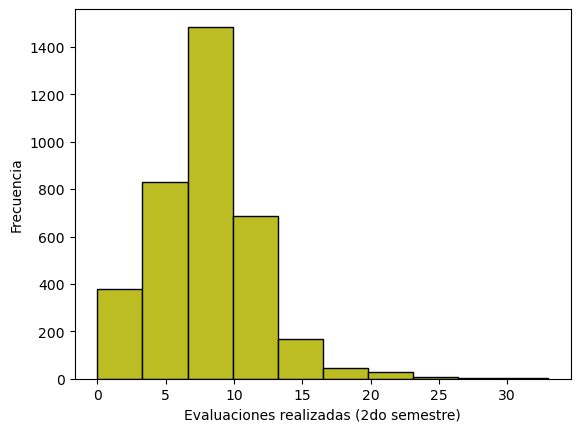

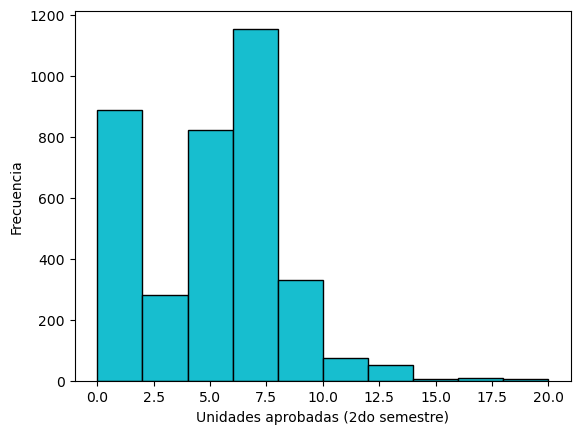

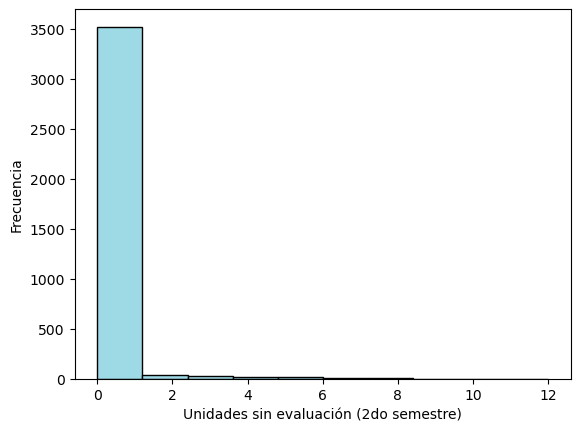

In [11]:
# Variables de tipo entero
cols_int = datos.select_dtypes(include = "int64").columns

# Colores
n = len(cols_int)
colors = plt.cm.tab20(np.linspace(0, 1, n))

# Se grafica para cada variable
for i, col in enumerate(cols_int):
    
    plt.figure()
    
    plt.hist(datos[col], color = colors[i], edgecolor = "black")
    
    plt.xlabel(name_col(col))
    plt.ylabel("Frecuencia")
    
    plt.show()

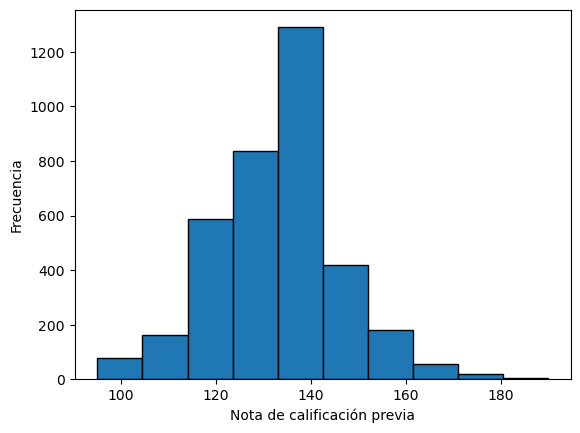

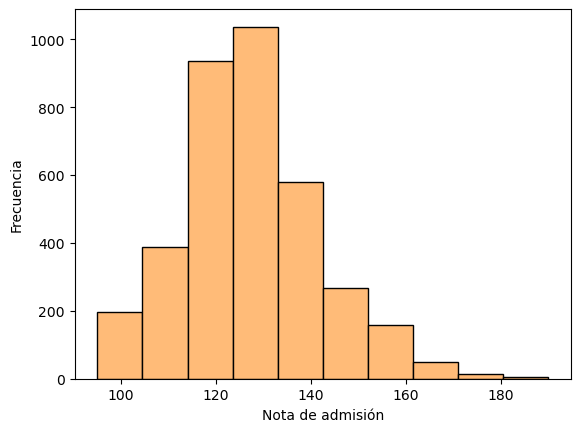

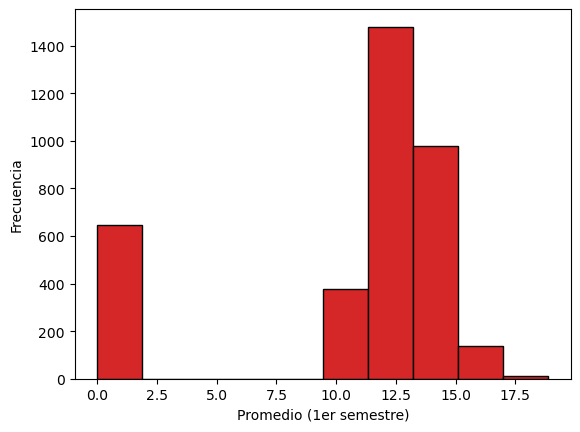

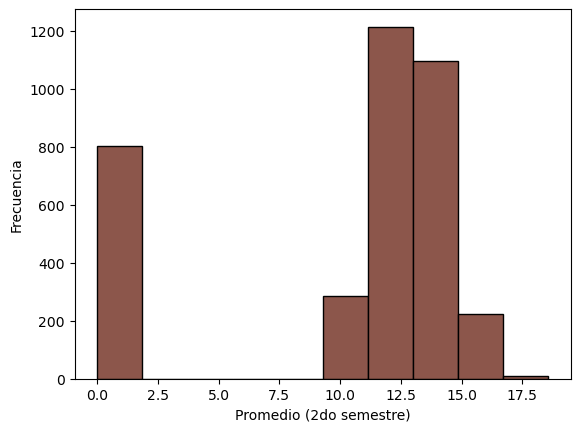

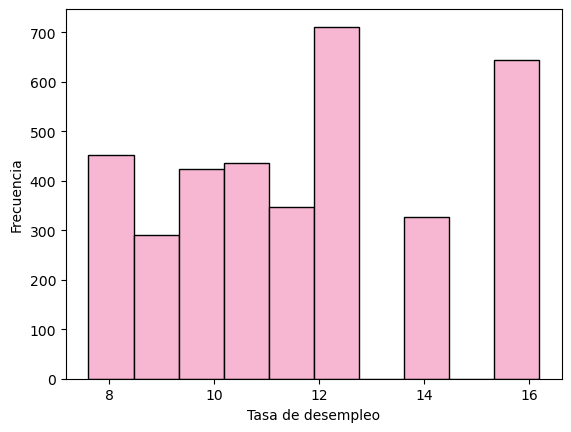

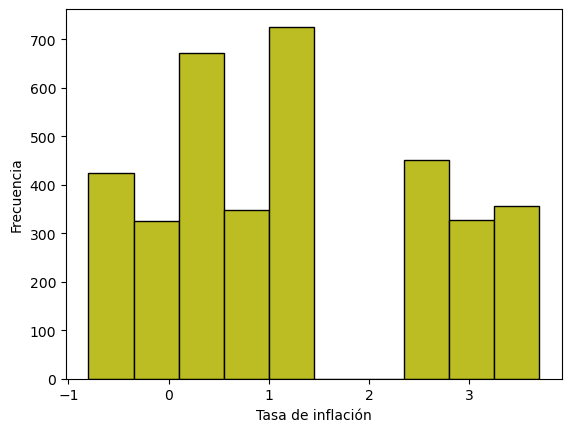

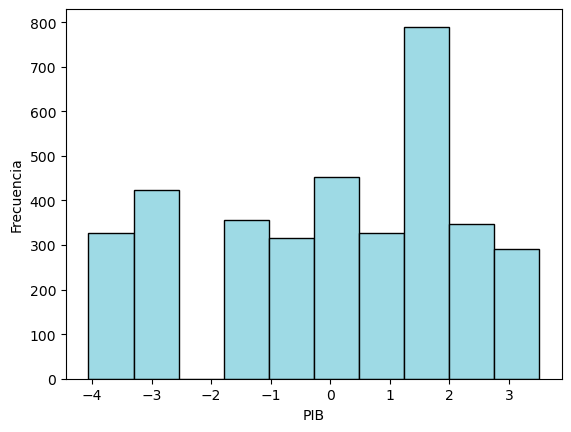

In [12]:
warnings.filterwarnings("ignore")

# Variables de tipo float
cols_float = datos.select_dtypes(include = "float64").columns

# Colores
n = len(cols_float)
colors = plt.cm.tab20(np.linspace(0, 1, n))

# Se grafica para cada variable
for i, col in enumerate(cols_float):
    
    plt.figure()
    
    plt.hist(datos[col], color = colors[i], edgecolor = "black")
    
    plt.xlabel(name_col(col))
    plt.ylabel("Frecuencia")
    
    plt.show()

## Boxplots

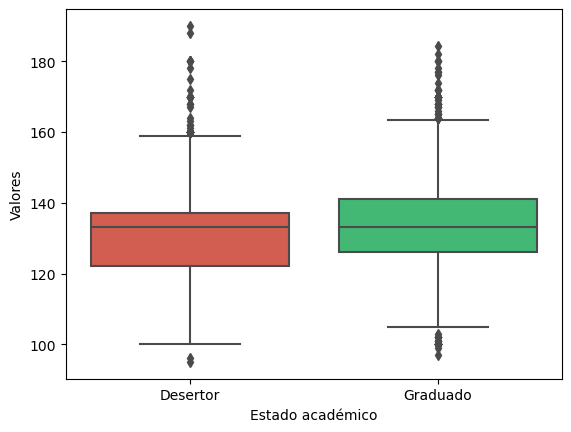

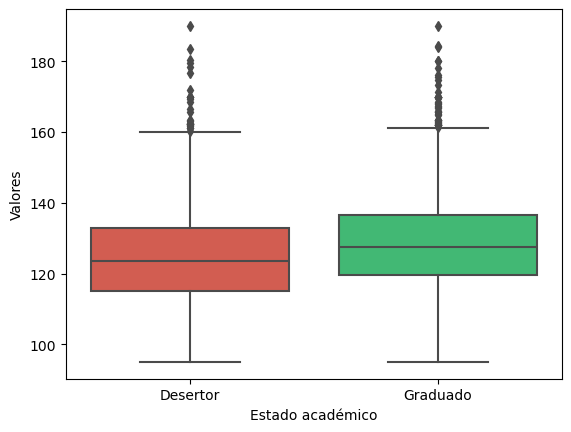

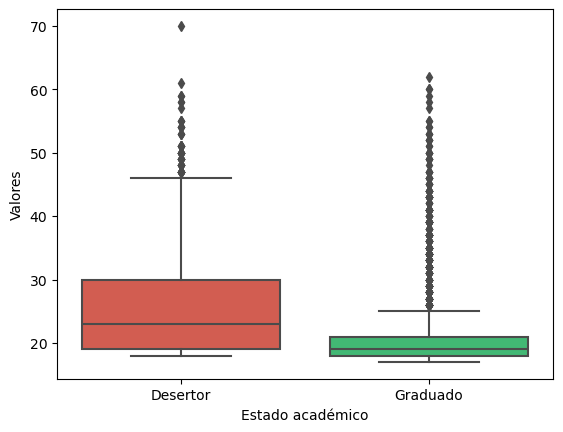

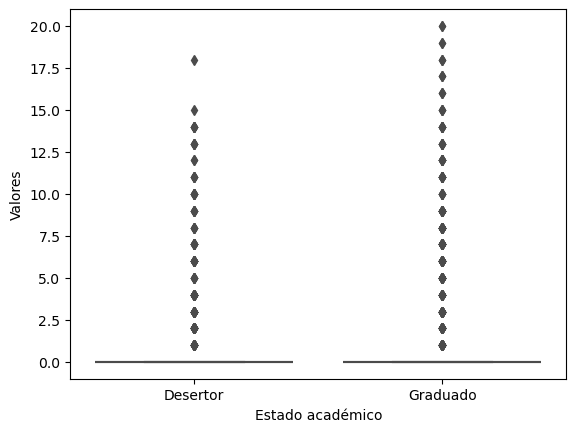

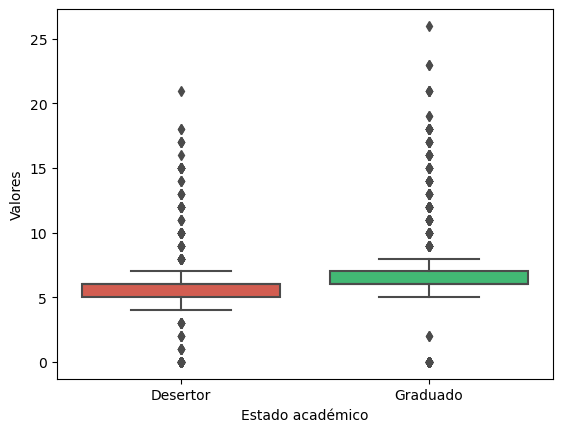

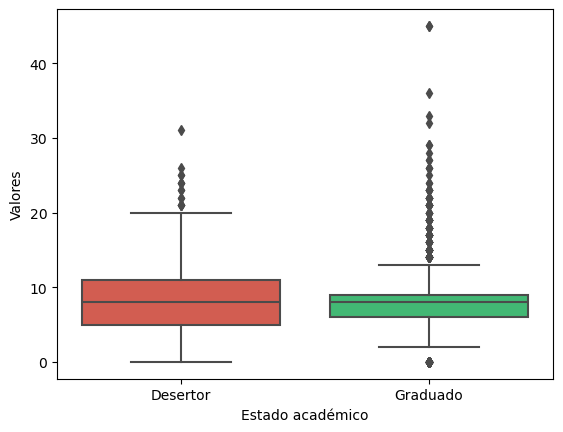

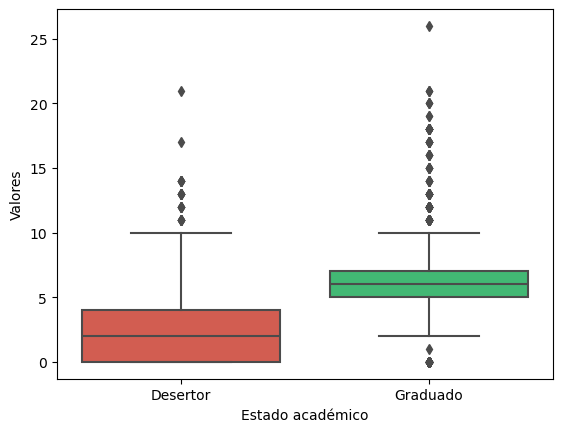

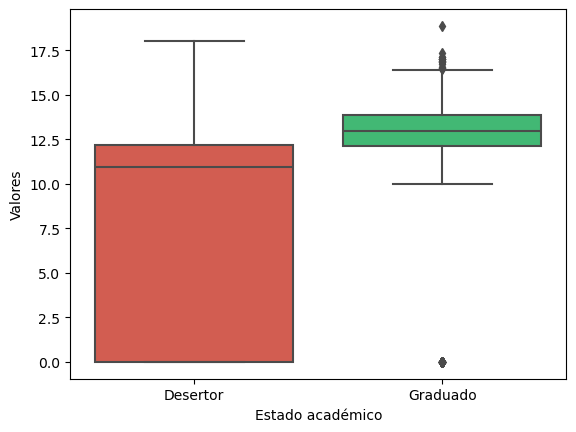

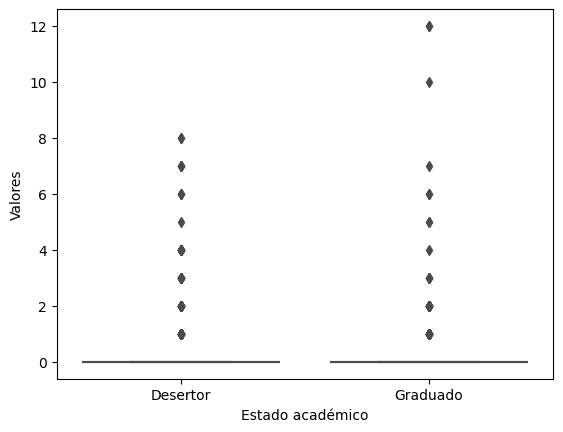

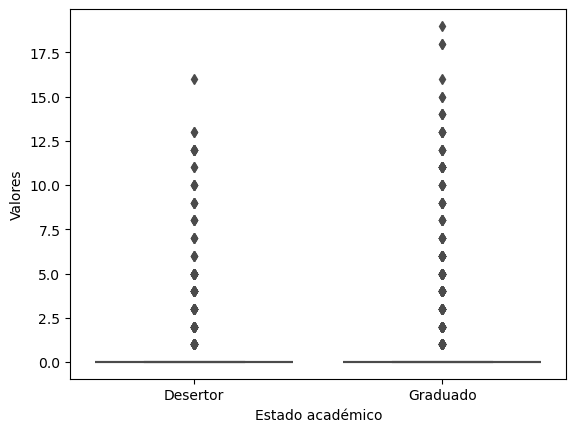

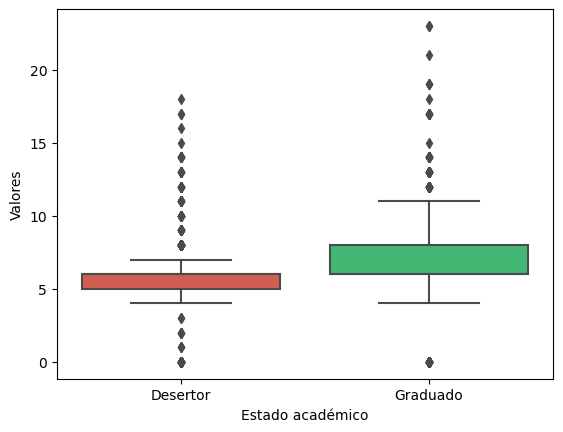

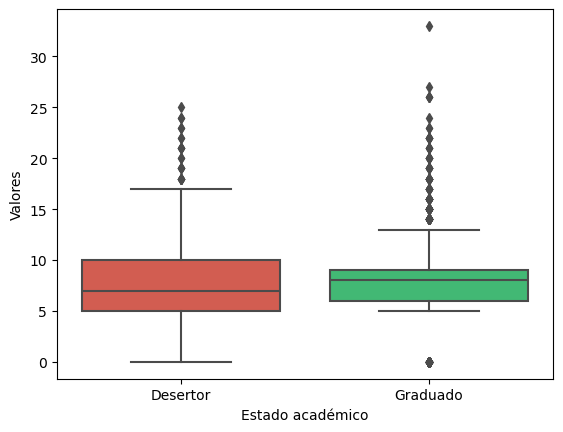

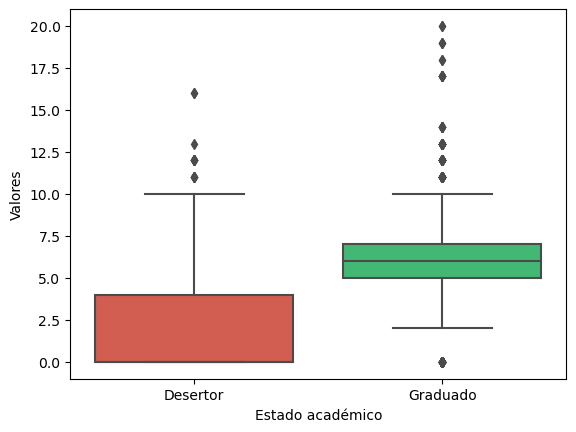

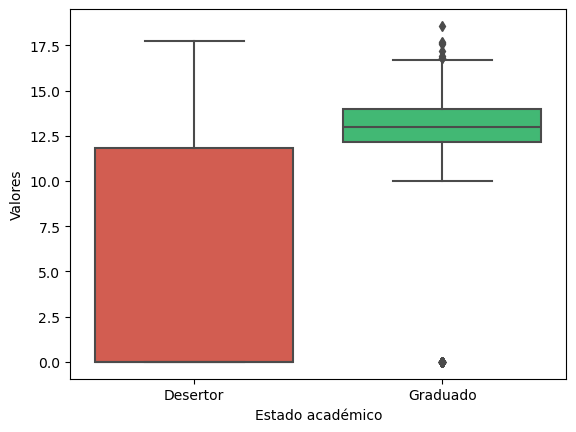

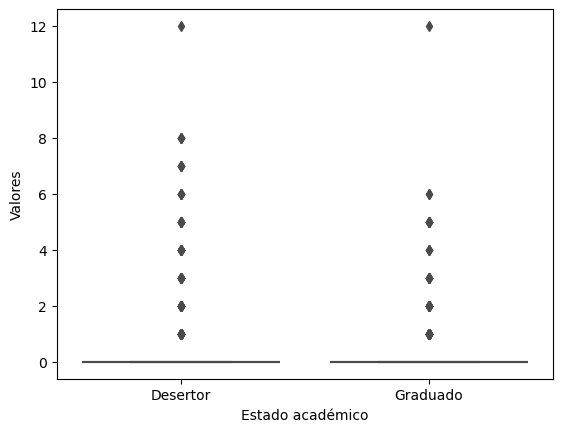

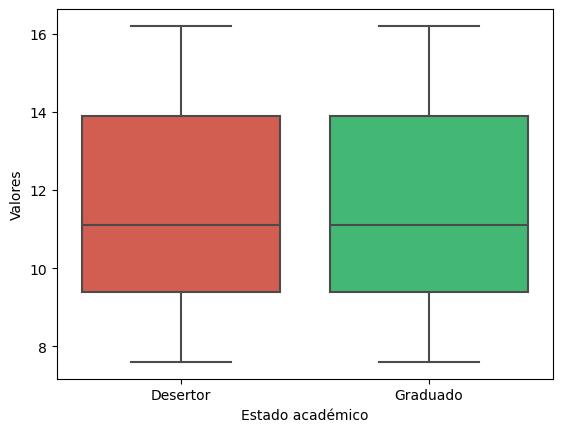

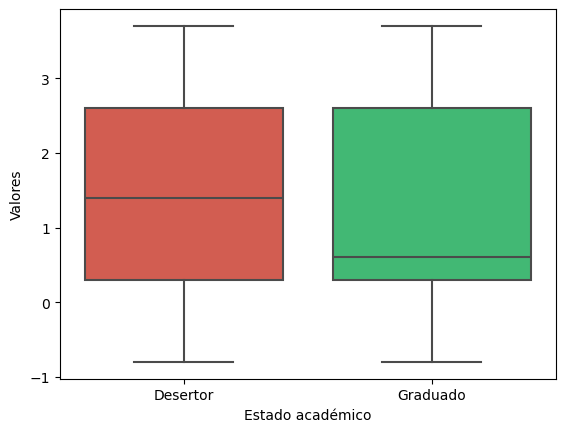

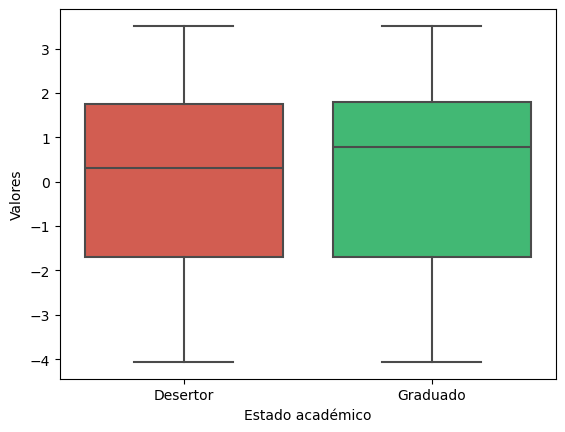

In [13]:
# Variables numéricas (int64 + float64)
cols_num = datos.select_dtypes(include = ["int64", "float64"]).columns

# Se grafica para cada variable
for col in cols_num:
    
    plt.figure()
    
    # Se discrimina por la variable objetivo
    ax = sns.boxplot(
        x = "target",
        y = col,
        data = datos,
        palette = ["#e74c3c", "#2ecc71"]
    )
    
    # Se cambian las etiquetas del eje X
    ax.set_xticklabels(["Desertor", "Graduado"])
    
    plt.xlabel("Estado académico")
    plt.ylabel("Valores")
    
    plt.show()

## De dispersión

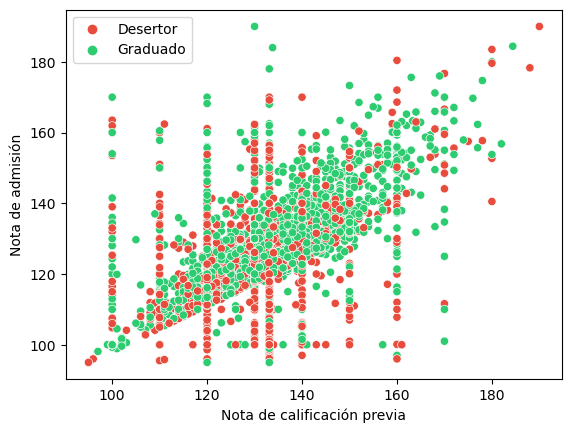

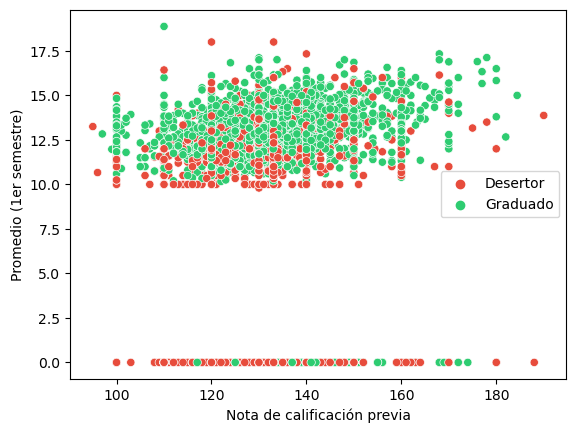

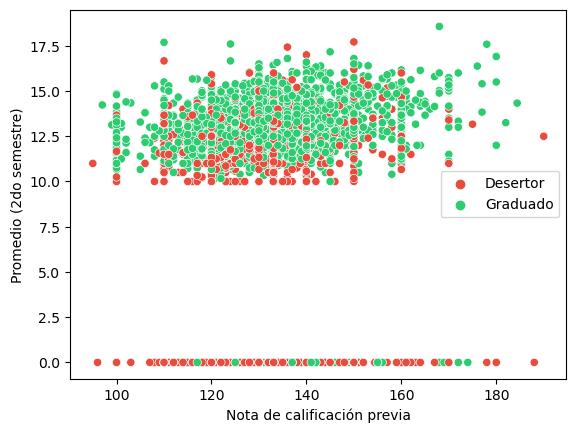

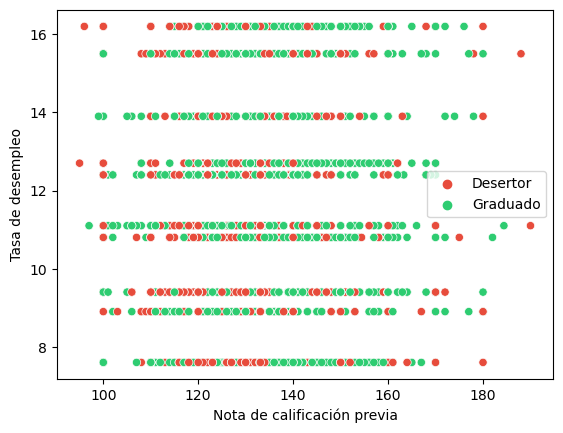

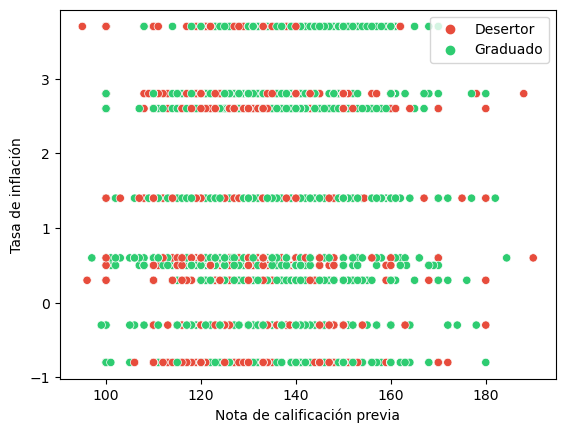

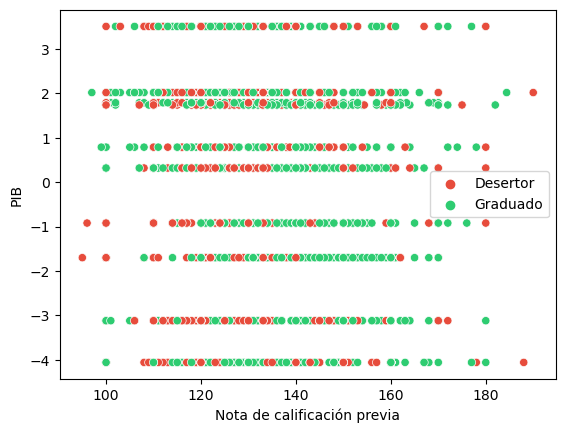

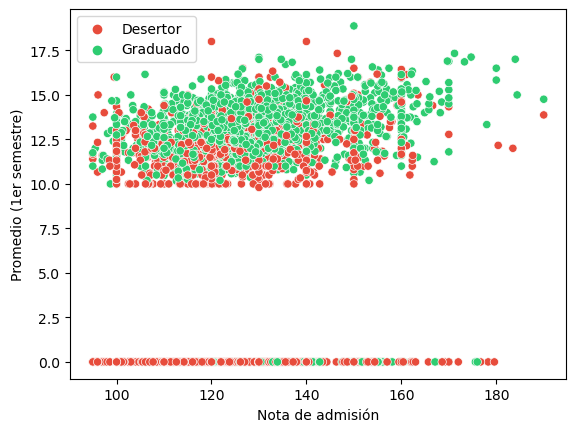

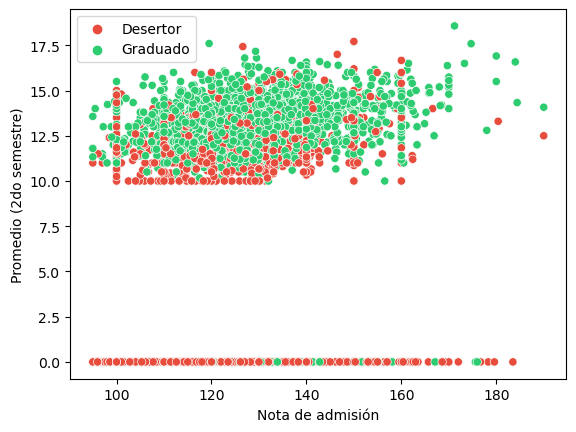

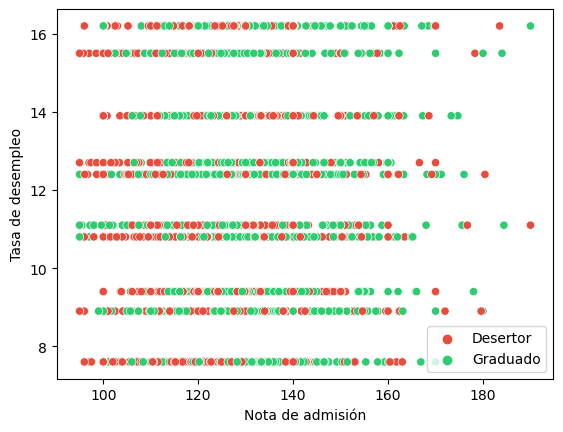

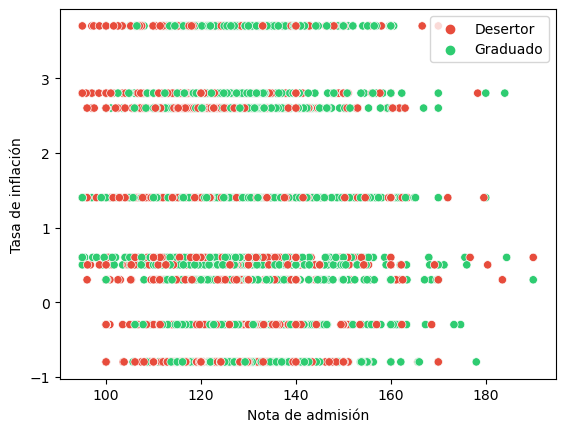

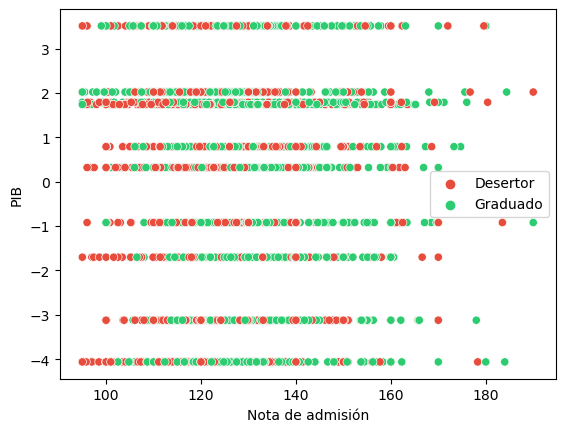

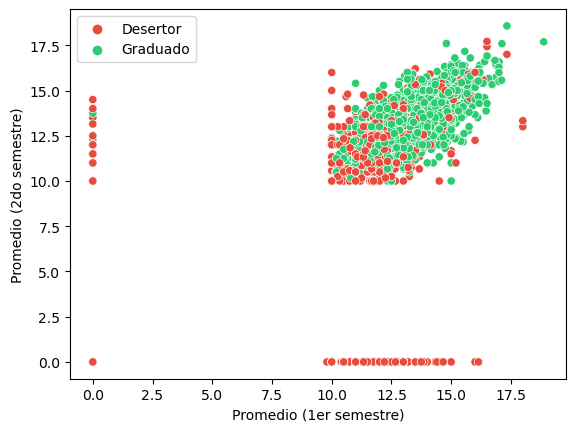

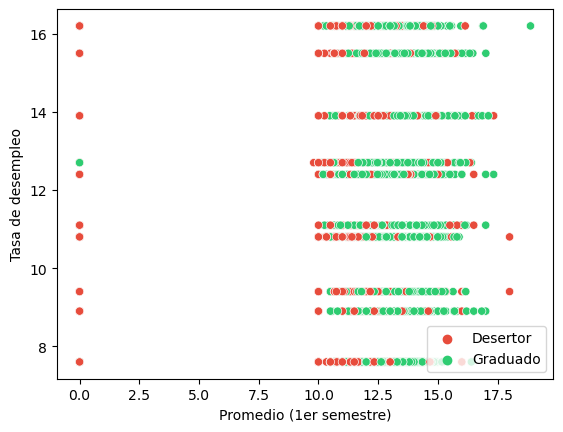

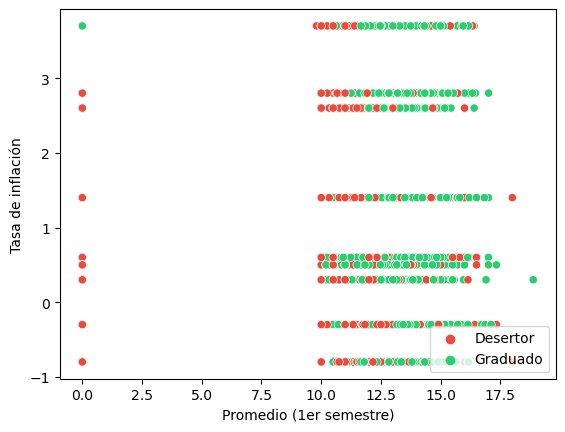

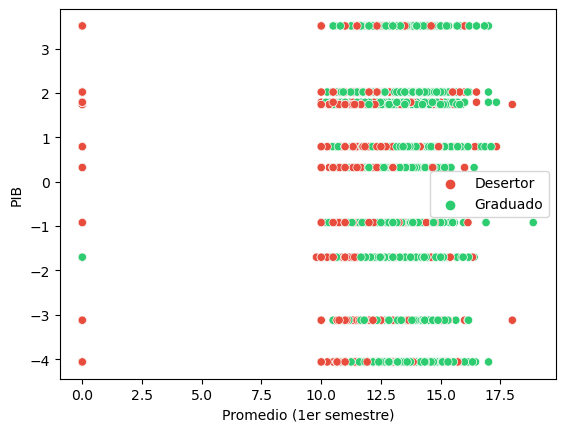

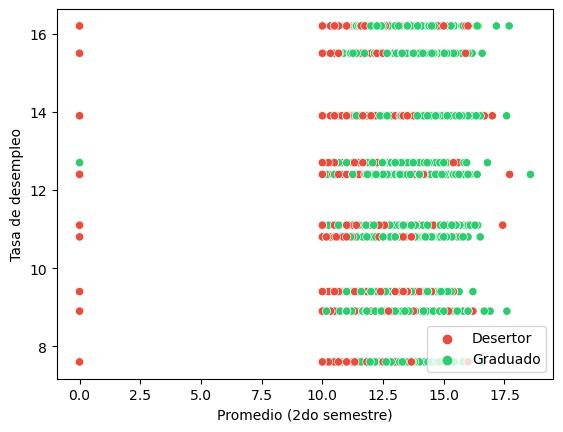

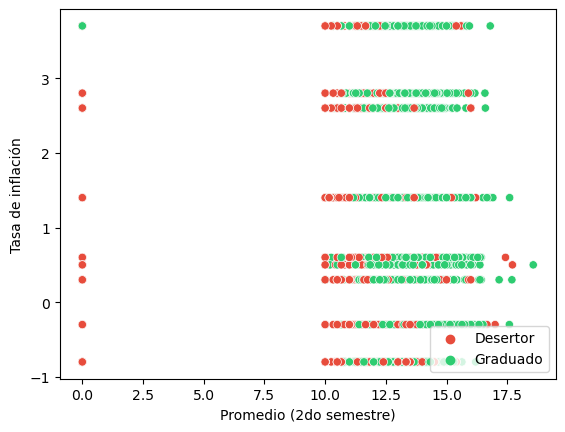

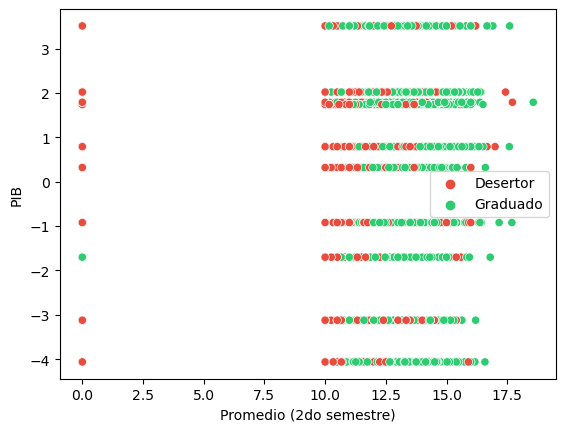

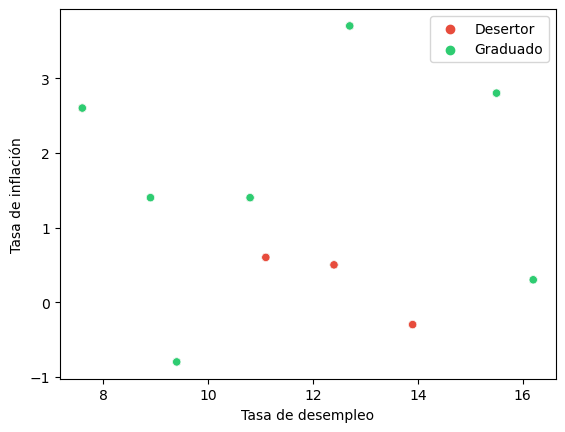

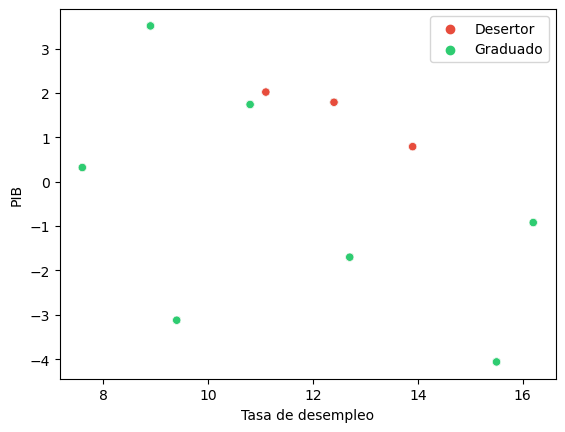

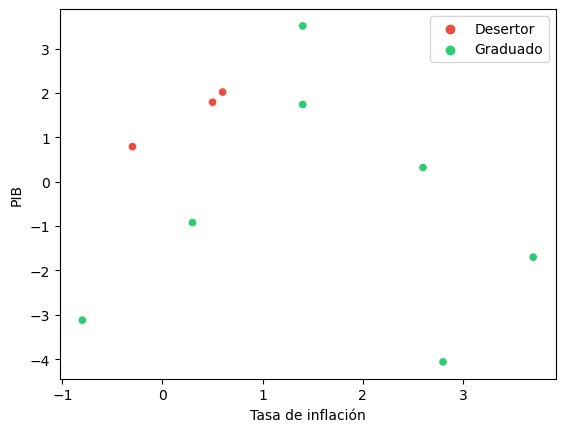

In [14]:
# Combinaciones de variables de tipo float64
pairs = itertools.combinations(cols_float, 2)

# Se grafica para cada par de variables
for x_col, y_col in pairs:
    
    plt.figure()
    
    ax = sns.scatterplot(
        x = x_col,
        y = y_col,
        hue = "target",
        data = datos,
        palette = ["#e74c3c", "#2ecc71"]
    )
    
    # Se cambian las etiquetas de las categorías de la variable objetivo
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles = handles,
        labels = ["Desertor", "Graduado"]
    )
    
    plt.xlabel(name_col(x_col))
    plt.ylabel(name_col(y_col))
    
    plt.show()